# Data Science Fundamentals with Python | Learners' Space 2026
## Mohit Khyalia
### 24B2289
#### Worksheet 2 — Question 2: Time Series Analysis & AR Model


---
## Part 1: Theory Questions

### Q1. Difference Between ACF and PACF

**AutoCorrelation Function (ACF)**

The ACF at lag *k* measures the Pearson correlation between the time series {yₜ} and its
lagged version {yₜ₋ₖ}, *without* removing the influence of the intermediate lags.

- ACF(k) = Corr(yₜ, yₜ₋ₖ) — includes *both* direct and indirect effects.
- For a stationary series it decays toward zero as k increases.
- **Interpretation table:**

| Model | ACF pattern | PACF pattern |
|-------|-------------|--------------|
| AR(p) | Decays gradually (tails off) | Cuts off sharply after lag p |
| MA(q) | Cuts off sharply after lag q | Decays gradually (tails off) |
| ARMA(p,q) | Tails off | Tails off |

- **Use:** Identify the MA order **q** (ACF cuts off after q).

---

**Partial AutoCorrelation Function (PACF)**

The PACF at lag *k* measures the *direct* (partial) correlation between yₜ and yₜ₋ₖ
after partialling out (linearly removing) the effect of all intermediate lags
yₜ₋₁, yₜ₋₂, …, yₜ₋ₖ₊₁.

- It isolates the unique marginal contribution of lag k.
- **Use:** Identify the AR order **p** (PACF cuts off after p).

---

**Summary:**

| Aspect | ACF | PACF |
|--------|-----|------|
| What it measures | Total correlation at lag k | Direct (net) correlation at lag k |
| Intermediate lags removed? | No | Yes |
| Used to determine | MA order q | AR order p |


### Q2. Identifying the Optimal AR Order Using ACF and PACF

**Step-by-step procedure:**

1. **Check stationarity** — plot the series; if a clear upward/downward trend or
   changing variance is visible, apply differencing (or log-transform + differencing)
   until the series is stationary.

2. **Plot the ACF** — for an AR process the ACF decays *gradually* (exponentially
   or oscillating). A slow decay confirms an AR component is present.

3. **Plot the PACF** — the PACF of an AR(p) process drops to *near zero* (inside the
   95 % confidence bands shown as dashed lines) **after lag p**.  
   - Identify the last lag k where |PACF(k)| is *outside* the confidence band.
   - That lag is the candidate **p**.

4. **Fit candidate models** — fit AR(1), AR(2), … AR(p_max) and compare using
   information criteria:
   - **AIC** (Akaike Information Criterion) — balance fit and complexity.
   - **BIC** (Bayesian Information Criterion) — penalises complexity more heavily.
   - Choose the **p** that minimises AIC/BIC.

5. **Validate on hold-out data** — compare RMSE / MAE on a test set for the top
   candidate orders.

**Practical rule of thumb:**  
*If the PACF has a significant spike only at lag 1 → AR(1). Significant at lags 1
and 2 but not 3 → AR(2). And so on.*


---
## Part 2: Time Series Analysis — Air Passengers Dataset

### Section 1: Load and Visualize the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/mohitkhyalia1/data-science-fundamentals-python/main/Week%202/AirPassengers.csv"

df = pd.read_csv(url)
print(df.shape)
print(df.head())


(144, 2)
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [2]:
# Parse Month column and set as DateTimeIndex
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df = df.set_index('Month')
df.columns = ['Passengers']
df.index.freq = 'MS'   # Month Start frequency

print("Date range :", df.index[0].date(), "→", df.index[-1].date())
print("Total months:", len(df))
df.head(12)


Date range : 1949-01-01 → 1960-12-01
Total months: 144


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


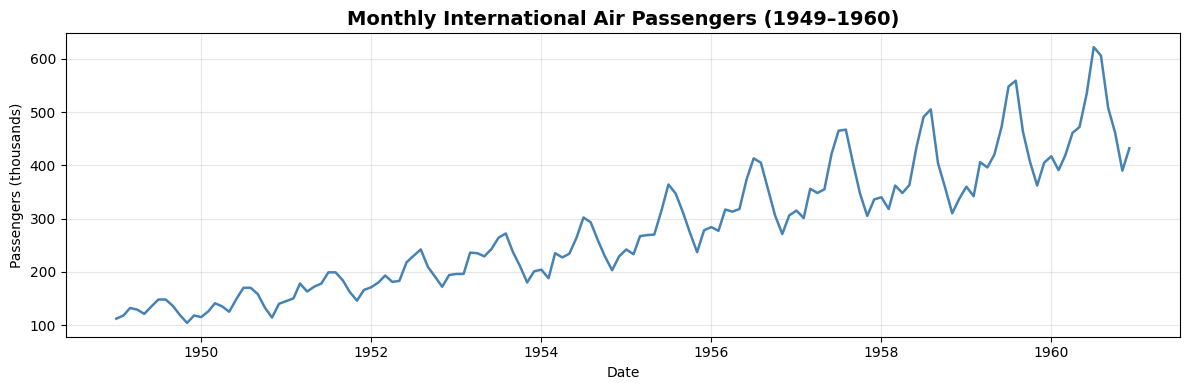

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Passengers'], color='steelblue', linewidth=1.8)
plt.title('Monthly International Air Passengers (1949–1960)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Section 2: ACF and PACF Plots — Lag Selection

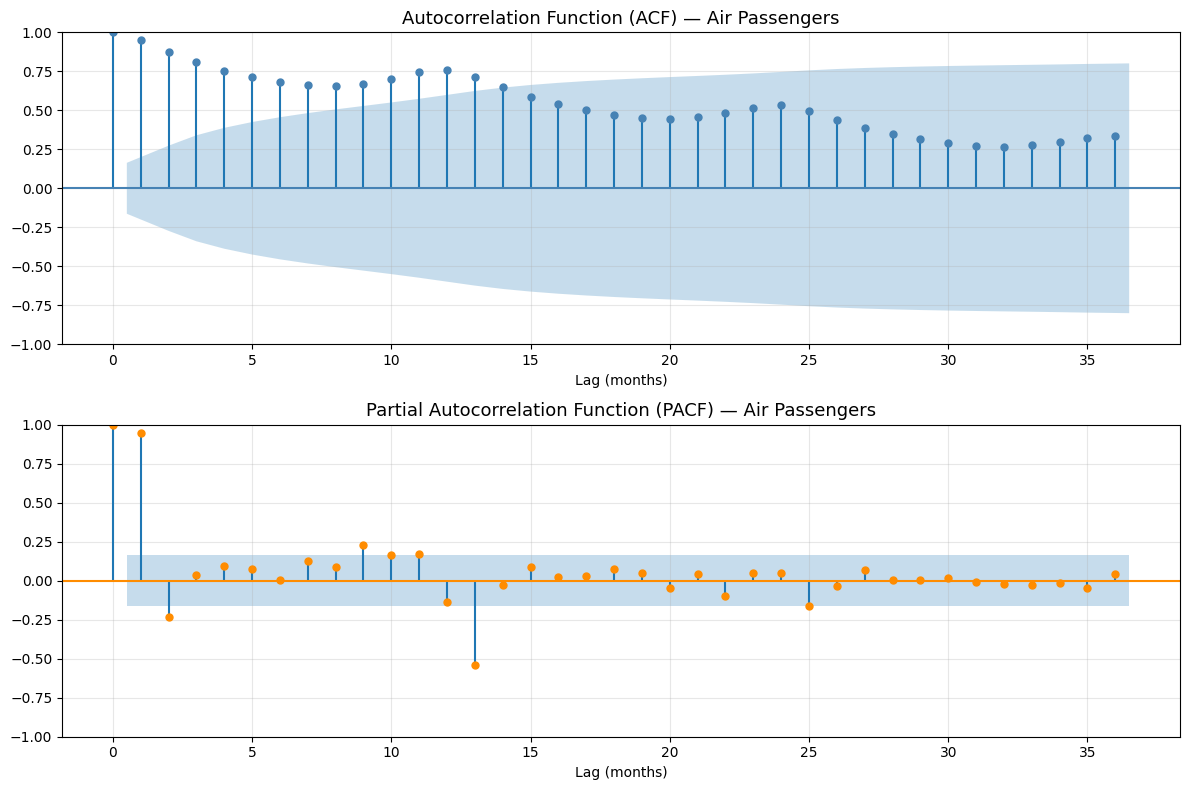

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['Passengers'],  lags=36, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) — Air Passengers', fontsize=13)
axes[0].set_xlabel('Lag (months)')
axes[0].grid(True, alpha=0.3)

plot_pacf(df['Passengers'], lags=36, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) — Air Passengers', fontsize=13)
axes[1].set_xlabel('Lag (months)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### ACF / PACF Interpretation

The ACF shows a gradual decay, while the PACF has significant spikes at the initial lags and around lag 12–13.

Based on the PACF plot, lag 13 was selected for the AR model as it captures both short-term dependencies and the yearly seasonal pattern present in the data.

### Section 3: Train / Test Split

In [5]:
train = df.loc['1949':'1959']
test  = df.loc['1960']

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} months)")
print(f"Test : {test.index[0].date()}  to {test.index[-1].date()}   ({len(test)} months)")


Train: 1949-01-01 to 1959-12-01  (132 months)
Test : 1960-01-01  to 1960-12-01   (12 months)


### Section 4: Fit AutoRegressive Model

In [6]:
LAG = 13   # chosen from PACF analysis

ar_model  = AutoReg(train['Passengers'], lags=LAG, old_names=False)
ar_result = ar_model.fit()

print(f"Selected AR Order: {LAG}")
print("Model training completed successfully.")

Selected AR Order: 13
Model training completed successfully.


### Section 5: Predictions and Evaluation

In [7]:
# Predict the 12 months of 1960 (indices len(train) to len(train)+11)
start_idx = len(train)
end_idx   = len(train) + len(test) - 1

preds = ar_result.predict(start=start_idx, end=end_idx)
preds.index = test.index

# Comparison table
comparison = pd.DataFrame({
    'Actual'    : test['Passengers'].values,
    'Predicted' : preds.values.round(1),
    'Abs Error' : np.abs(test['Passengers'].values - preds.values).round(1),
    'Pct Error' : (np.abs(test['Passengers'].values - preds.values) /
                   test['Passengers'].values * 100).round(2)
}, index=test.index.strftime('%Y-%m'))

print(comparison.to_string())


         Actual  Predicted  Abs Error  Pct Error
Month                                           
1960-01     417      416.5        0.5       0.11
1960-02     391      396.7        5.7       1.45
1960-03     419      455.8       36.8       8.77
1960-04     461      443.1       17.9       3.89
1960-05     472      471.3        0.7       0.15
1960-06     535      523.8       11.2       2.10
1960-07     622      607.5       14.5       2.33
1960-08     606      618.5       12.5       2.06
1960-09     508      512.9        4.9       0.97
1960-10     461      449.9       11.1       2.40
1960-11     390      399.3        9.3       2.38
1960-12     432      450.0       18.0       4.16


In [8]:
y_actual = test['Passengers'].values
y_pred   = preds.values

mse_val  = mean_squared_error(y_actual, y_pred)
rmse_val = np.sqrt(mse_val)
r2_val   = r2_score(y_actual, y_pred)

print(f"\nEvaluation Metrics — AR({LAG}) on 1960 Test Set")
print(f"  MSE  : {mse_val:.2f}")
print(f"  RMSE : {rmse_val:.2f}")
print(f"  R²   : {r2_val:.4f}")



Evaluation Metrics — AR(13) on 1960 Test Set
  MSE  : 229.45
  RMSE : 15.15
  R²   : 0.9586


### Section 6: Visualization — Results

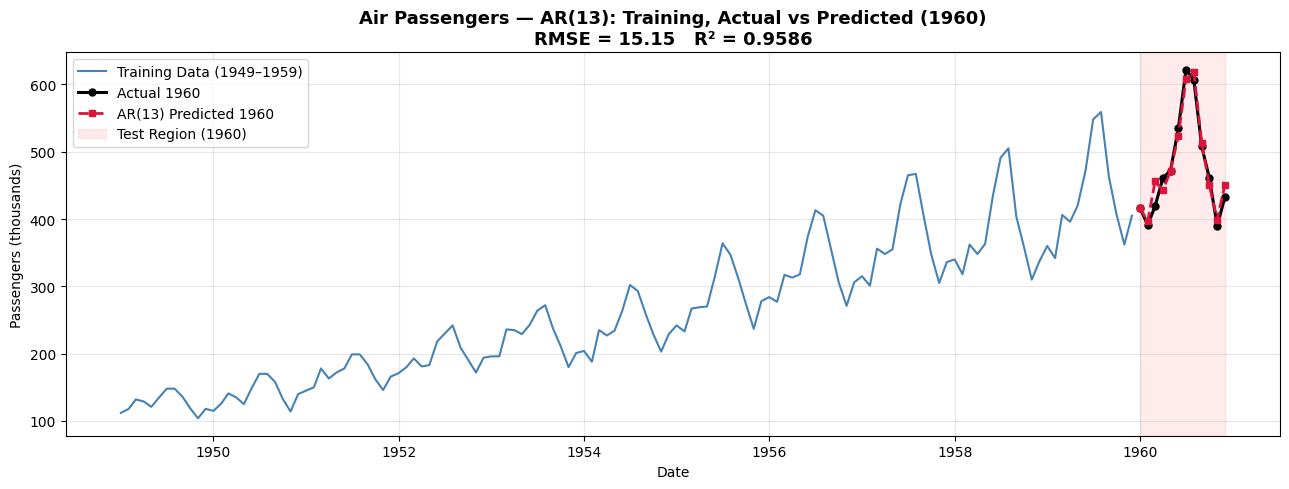

In [9]:
plt.figure(figsize=(13, 5))

# Training series
plt.plot(train.index, train['Passengers'],
         color='steelblue', linewidth=1.5, label='Training Data (1949–1959)')

# Actual 1960 values
plt.plot(test.index, test['Passengers'],
         color='black', linewidth=2.2, linestyle='-',
         marker='o', markersize=5, label='Actual 1960')

# AR predictions
plt.plot(preds.index, preds,
         color='crimson', linewidth=2, linestyle='--',
         marker='s', markersize=5, label=f'AR({LAG}) Predicted 1960')

# Shade test region
plt.axvspan(test.index[0], test.index[-1],
            alpha=0.08, color='red', label='Test Region (1960)')

plt.title(
    f'Air Passengers — AR({LAG}): Training, Actual vs Predicted (1960)\n'
    f'RMSE = {rmse_val:.2f}   R² = {r2_val:.4f}',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


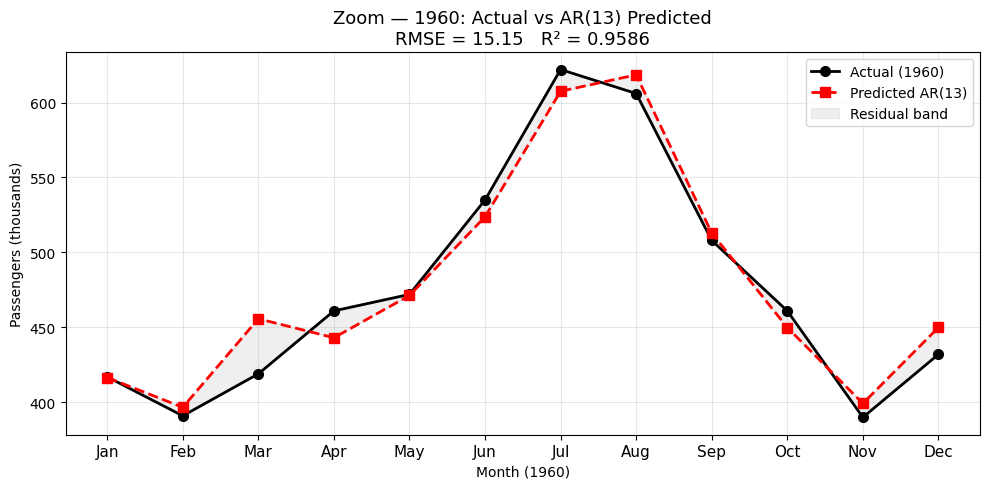

In [10]:
# ── Zoomed: 1960 month-by-month ───────────────────────────────────────
months_lbl = test.index.strftime('%b')
x = np.arange(12)

plt.figure(figsize=(10, 5))
plt.plot(x, y_actual, 'ko-', linewidth=2, markersize=7, label='Actual (1960)')
plt.plot(x, y_pred,   'rs--',linewidth=2, markersize=7, label=f'Predicted AR({LAG})')
plt.fill_between(x, y_actual, y_pred, alpha=0.12, color='gray', label='Residual band')
plt.xticks(x, months_lbl, fontsize=11)
plt.xlabel('Month (1960)')
plt.ylabel('Passengers (thousands)')
plt.title(
    f'Zoom — 1960: Actual vs AR({LAG}) Predicted\n'
    f'RMSE = {rmse_val:.2f}   R² = {r2_val:.4f}',
    fontsize=13
)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The AR(13) model was able to predict the passenger data reasonably well. The predicted values were close to the actual values, indicating good model performance on the test set.
